#### **LAB 05: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)**

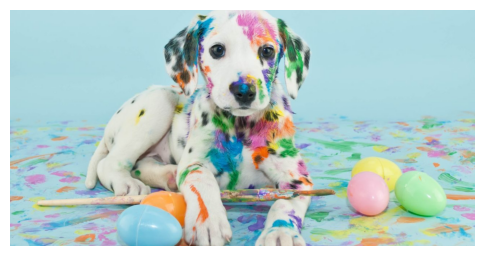

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def show(title, img, cmap='gray'):
    plt.figure(figsize=(6,4))
    plt.title(title)
    plt.axis('off')
    plt.imshow(img, cmap=cmap)

img = cv.imread('hinh1.png')
plt.figure(figsize=(6,4))
plt.axis('off')
plt.imshow(img[:,:,::-1])
plt.show()

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

**1. Thresholding để phân đoạn ảnh**

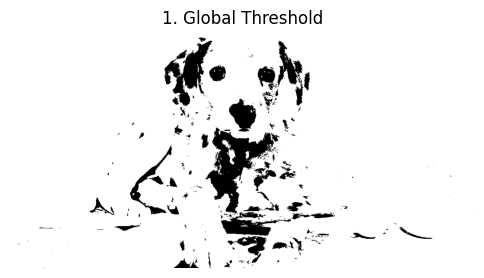

In [3]:
_, th_global = cv.threshold(gray, 128, 255, cv.THRESH_BINARY)
show("1. Global Threshold", th_global)

**2. Otsu algorithm để phân đoạn ảnh vân tay** 

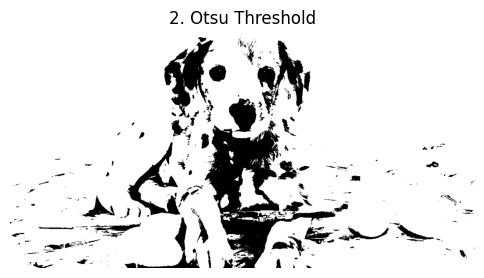

In [4]:
_, th_otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
show("2. Otsu Threshold", th_otsu)

**3. Clustering techniques trong phân đoạn ảnh, K-mean clustering**

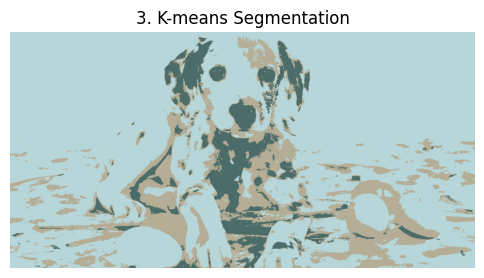

In [5]:
Z = img.reshape((-1,3)).astype(np.float32)
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
_, labels, centers = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
res = centers[labels.flatten()].reshape(img.shape)
show("3. K-means Segmentation", cv.cvtColor(res, cv.COLOR_BGR2RGB), cmap=None)

**4. Sử dụng thuật toán Region growing**

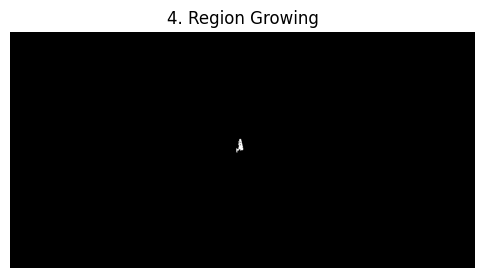

In [6]:
def region_grow(img, seed, thresh=10):
    h,w = img.shape
    out = np.zeros_like(img, np.uint8)
    visited = np.zeros_like(img, np.bool_)
    stack = [seed]
    seed_val = int(img[seed[1], seed[0]])
    while stack:
        x,y = stack.pop()
        if visited[y,x]:
            continue
        visited[y,x] = True
        cur = int(img[y,x])
        if abs(cur - seed_val) <= thresh:
            out[y,x] = 255
            for dx,dy in ((1,0),(-1,0),(0,1),(0,-1)):
                nx, ny = x+dx, y+dy
                if 0 <= nx < w and 0 <= ny < h and not visited[ny,nx]:
                    stack.append((nx,ny))
    return out

h,w = gray.shape
seed_point = (w//2, h//2)
rg = region_grow(gray, seed_point, thresh=15)
show("4. Region Growing", rg)

**5. Sử dụng thuật toán Split and merge để phân đoạn ảnh**

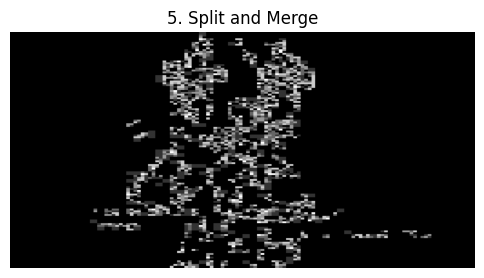

In [7]:
def split_quadtree(img, x, y, w, h, thr_var=500):
    patch = img[y:y+h, x:x+w]
    if w <= 8 or h <= 8 or np.var(patch) <= thr_var:
        return [(x,y,w,h)]
    hw, hh = w//2, h//2
    nodes = []
    nodes += split_quadtree(img, x, y, hw, hh, thr_var)
    nodes += split_quadtree(img, x+hw, y, w-hw, hh, thr_var)
    nodes += split_quadtree(img, x, y+hh, hw, h-hh, thr_var)
    nodes += split_quadtree(img, x+hw, y+hh, w-hw, h-hh, thr_var)
    return nodes

regions = split_quadtree(gray, 0, 0, w, h, thr_var=400)
merge_img = np.zeros_like(gray)
for (x,y,ww,hh) in regions:
    merge_img[y:y+hh, x:x+ww] = np.mean(gray[y:y+hh, x:x+ww], dtype=np.uint8)
show("5. Split and Merge", merge_img)

**6. Phân đoạn ảnh với Edge-based sigmentation**

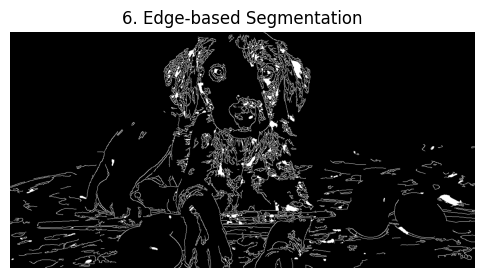

In [8]:
edges = cv.Canny(gray, 50, 150)
contours,_ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
edge_seg = np.zeros_like(gray)
cv.drawContours(edge_seg, contours, -1, (255), thickness=cv.FILLED)
show("6. Edge-based Segmentation", edge_seg)